Cell 1 - Import Libraries

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

Cell 2 - Load Dataset

In [33]:
branches = pd.read_csv("../data/raw/branches.csv")
customers = pd.read_csv("../data/raw/customers.csv")
inventory = pd.read_csv("../data/raw/inventory_master.csv")
invoices = pd.read_csv("../data/raw/invoices.csv")
payments = pd.read_csv("../data/raw/payments.csv")
products = pd.read_csv("../data/raw/products.csv")
po_header = pd.read_csv("../data/raw/purchase_orders_header.csv")
po_lines = pd.read_csv("../data/raw/purchase_orders_lines.csv")
sales_header = pd.read_csv("../data/raw/sales_orders_header.csv")
sales_lines = pd.read_csv("../data/raw/sales_orders_lines.csv")
stock = pd.read_csv("../data/raw/stock_ledger.csv")
suppliers = pd.read_csv("../data/raw/suppliers.csv")

Cell 3 - Store in Dictionary

In [34]:
datasets = {
    "Branches": branches,
    "Customers": customers,
    "Inventory": inventory,
    "Invoices": invoices,
    "Payments": payments,
    "Products": products,
    "Purchase Header": po_header,
    "Purchase Lines": po_lines,
    "Sales Header": sales_header,
    "Sales Lines": sales_lines,
    "Stock Ledger": stock,
    "Suppliers": suppliers
}

Cell 4 - Dataset Summary

In [35]:
summary = pd.DataFrame({
    "Dataset":[name for name in datasets.keys()],
    "Rows":[df.shape[0] for df in datasets.values()],
    "Columns":[df.shape[1] for df in datasets.values()]
})

summary

,Dataset,Rows,Columns
0,Branches,6,13
1,Customers,500,15
2,Inventory,180,8
3,Invoices,18033,10
4,Payments,19257,5
5,Products,30,23
6,Purchase Header,24000,10
7,Purchase Lines,155495,9
8,Sales Header,20000,11
9,Sales Lines,130402,9


Cell 5 - Dataset Information

In [36]:
for name, df in datasets.items():
    print("="*60)
    print(name)
    print("="*60)
    print(df.info())

Branches
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   branch_id                 6 non-null      object
 1   branch_name               6 non-null      object
 2   city                      6 non-null      object
 3   state                     6 non-null      object
 4   region                    6 non-null      object
 5   warehouse_type            6 non-null      object
 6   warehouse_capacity        6 non-null      object
 7   service_center_available  6 non-null      object
 8   manager_id                6 non-null      int64 
 9   total_employees           6 non-null      int64 
 10  avg_monthly_revenue       6 non-null      int64 
 11  monthly_operational_cost  6 non-null      int64 
 12  market_demand_index       6 non-null      int64 
dtypes: int64(5), object(8)
memory usage: 756.0+ bytes
None
Customers
<class 'pa

Cell 6 - Missing Values

In [37]:
for name, df in datasets.items():
    print("\n")
    print("="*60)
    print(name)
    print("="*60)
    print(df.isnull().sum())



Branches
branch_id                   0
branch_name                 0
city                        0
state                       0
region                      0
warehouse_type              0
warehouse_capacity          0
service_center_available    0
manager_id                  0
total_employees             0
avg_monthly_revenue         0
monthly_operational_cost    0
market_demand_index         0
dtype: int64


Customers
customer_id             0
customer_type           0
industry_segment        0
city                    0
state                   0
pincode                 0
region                  0
branch_id               0
credit_limit            0
current_balance         0
payment_terms           0
customer_since          0
last_purchase_date      0
total_purchase_value    0
customer_rating         0
dtype: int64


Inventory
product_id       0
branch_id        0
opening_stock    0
reorder_level    0
safety_stock     0
max_stock        0
current_stock    0
warehouse_bin    0
dtype: 

Cell 7 - Duplicate Records

In [38]:
duplicates = pd.DataFrame({
    "Dataset":[name for name in datasets.keys()],
    "Duplicate Rows":[df.duplicated().sum() for df in datasets.values()]
})

duplicates

,Dataset,Duplicate Rows
0,Branches,0
1,Customers,0
2,Inventory,0
3,Invoices,0
4,Payments,0
5,Products,0
6,Purchase Header,0
7,Purchase Lines,0
8,Sales Header,0
9,Sales Lines,0


Cell 8 - Descriptive Statistics

In [39]:
for name, df in datasets.items():
    print("\n")
    print("="*70)
    print(name)
    print("="*70)
    display(df.describe(include="all"))



Branches


,branch_id,branch_name,city,state,region,warehouse_type,warehouse_capacity,service_center_available,manager_id,total_employees,avg_monthly_revenue,monthly_operational_cost,market_demand_index
count,6,6,6,6,6,6,6,6,6.000000,6.000000,6.000000e+00,6.000000e+00,6.000000
unique,6,6,6,6,4,4,6,2,NaN,NaN,NaN,NaN,NaN
top,DEL001,Delhi Central,Delhi,Delhi,West,Regional,45230 sqft,Yes,NaN,NaN,NaN,NaN,NaN
freq,1,1,1,1,2,2,1,4,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6462.000000,69.333333,3.905818e+06,2.371667e+06,7.500000
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1971.624204,15.983325,9.530291e+05,5.723431e+05,1.048809
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4390.000000,49.000000,2.894770e+06,1.743000e+06,6.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5074.250000,58.500000,3.138314e+06,1.919750e+06,7.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6047.500000,68.500000,3.817505e+06,2.336000e+06,7.500000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7470.000000,79.250000,4.523115e+06,2.717750e+06,8.000000




Customers


,customer_id,customer_type,industry_segment,city,state,pincode,region,branch_id,credit_limit,current_balance,payment_terms,customer_since,last_purchase_date,total_purchase_value,customer_rating
count,500,500,500,500,500,500.000000,500,500,5.000000e+02,5.000000e+02,500,500,500,5.000000e+02,500.00000
unique,500,5,6,21,16,NaN,6,6,NaN,NaN,5,467,449,NaN,NaN
top,C0500,Government,Mining,Chennai,Gujarat,NaN,South,CHN001,NaN,NaN,Net 45,2019-07-20,2024-02-17,NaN,NaN
freq,1,114,98,73,86,NaN,158,102,NaN,NaN,113,3,3,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,548696.582000,NaN,NaN,4.915253e+05,2.466805e+05,NaN,NaN,NaN,2.480429e+06,2.98200
std,NaN,NaN,NaN,NaN,NaN,267559.622805,NaN,NaN,3.720844e+05,2.588476e+05,NaN,NaN,NaN,1.454708e+06,1.40913
min,NaN,NaN,NaN,NaN,NaN,100171.000000,NaN,NaN,1.055200e+04,6.300000e+01,NaN,NaN,NaN,5.173000e+03,1.00000
25%,NaN,NaN,NaN,NaN,NaN,313057.000000,NaN,NaN,2.106442e+05,3.739025e+04,NaN,NaN,NaN,1.221794e+06,2.00000
50%,NaN,NaN,NaN,NaN,NaN,549304.000000,NaN,NaN,4.171450e+05,1.785700e+05,NaN,NaN,NaN,2.546906e+06,3.00000
75%,NaN,NaN,NaN,NaN,NaN,786612.750000,NaN,NaN,7.136942e+05,3.488998e+05,NaN,NaN,NaN,3.755662e+06,4.00000




Inventory


...

,so_id,line_number,product_id,quantity,unit_price,gst_rate,line_total,gst_amount,line_grand_total
count,130402,130402.000000,130402,130402.000000,130402.000000,130402.000000,1.304020e+05,130402.000000,1.304020e+05
unique,20000,NaN,30,NaN,NaN,NaN,NaN,NaN,NaN
top,SO-467856,NaN,P011,NaN,NaN,NaN,NaN,NaN,NaN
freq,12,NaN,4462,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,4.670672,NaN,10.494732,18528.782687,23.653748,1.951457e+05,53506.556616,2.486523e+05
std,NaN,2.924837,NaN,5.764858,25971.041338,4.957096,3.299368e+05,92810.616023,4.227138e+05
min,NaN,1.000000,NaN,1.000000,310.000000,18.000000,3.100000e+02,55.800000,3.658000e+02
25%,NaN,2.000000,NaN,6.000000,1450.000000,18.000000,1.224000e+04,2349.000000,1.446400e+04
50%,NaN,4.000000,NaN,10.000000,10200.000000,28.000000,6.760000e+04,15820.000000,8.425200e+04
75%,NaN,7.000000,NaN,15.000000,24500.000000,28.000000,2.205000e+05,61740.000000,2.822400e+05




Stock Ledger


,movement_id,product_id,branch_id,movement_type,movement_date,quantity,reference_type,reference_id,running_balance
count,237230,237230,237230,237230,237230,237230.000000,237230,237230,237230.000000
unique,237230,30,6,3,2218,NaN,3,43709,NaN
top,MOV-IN-70911,P012,CHN001,IN,2019-11-27,NaN,PO,SO-746072,NaN
freq,1,8082,44029,127611,214,NaN,127611,12,NaN
mean,NaN,NaN,NaN,NaN,NaN,91.007111,NaN,NaN,53439.071268
std,NaN,NaN,NaN,NaN,NaN,95.276281,NaN,NaN,31093.025775
min,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,14.000000
25%,NaN,NaN,NaN,NaN,NaN,11.000000,NaN,NaN,26531.000000
50%,NaN,NaN,NaN,NaN,NaN,40.000000,NaN,NaN,53240.500000
75%,NaN,NaN,NaN,NaN,NaN,170.000000,NaN,NaN,80015.000000




Suppliers


,supplier_id,supplier_name,supplier_type,product_category,city,province,region,pincode,lead_time_days,reliability_score,import_duty_rate,china_tax_id
count,8,8,8,8,8,8,8,8.000000,8.000000,8.00000,8.000000,8
unique,8,8,3,3,8,6,3,NaN,NaN,NaN,NaN,8
top,SUP0001,Shenzhen OEM Supplies,OEM,Small Parts,Shenzhen,Guangdong,East China,NaN,NaN,NaN,NaN,90SUZHOU398241
freq,1,1,3,3,1,2,5,NaN,NaN,NaN,NaN,1
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,559177.750000,17.375000,4.00000,9.500000,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,273893.541639,6.864765,0.92582,4.035556,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,202099.000000,10.000000,3.00000,5.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,327203.750000,11.500000,3.00000,7.250000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,561642.500000,17.000000,4.00000,8.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,713264.000000,20.750000,5.00000,12.750000,NaN


Cell 9 - First Five Rows

In [40]:
for name, df in datasets.items():
    print("="*60)
    print(name)
    display(df.head())

Branches


,branch_id,branch_name,city,state,region,warehouse_type,warehouse_capacity,service_center_available,manager_id,total_employees,avg_monthly_revenue,monthly_operational_cost,market_demand_index
0,DEL001,Delhi Central,Delhi,Delhi,North,Central,45230 sqft,Yes,9593,92,5234890,3189000,9
1,PUN001,Pune Distribution,Pune,Maharashtra,West,Regional,38750 sqft,Yes,6114,74,4389120,2654000,8
2,CHN001,Chennai South Hub,Chennai,Tamil Nadu,South,Regional,41890 sqft,Yes,7922,81,4567780,2739000,8
3,HYD001,Hyderabad Logistics,Hyderabad,Telangana,South,Branch,36210 sqft,No,4390,57,3102455,1887000,7
4,KOL001,Kolkata East Depot,Kolkata,West Bengal,East,Branch,29880 sqft,No,5981,49,2894770,1743000,6


Customers


,customer_id,customer_type,industry_segment,city,state,pincode,region,branch_id,credit_limit,current_balance,payment_terms,customer_since,last_purchase_date,total_purchase_value,customer_rating
0,C0001,Retail,Construction,Kolkata,West Bengal,991035,East,KOL001,45896,43284,Advance,2024-04-10,2024-04-25,3892818,4
1,C0002,Fleet Owner,Manufacturing,Hyderabad,Telangana,464589,South,HYD001,531506,426735,Advance,2022-01-19,2024-12-04,3168730,2
2,C0003,Government,Logistics,Surat,Gujarat,202475,West,DEL001,1306933,733495,Net 30,2017-02-14,2019-06-11,3584708,2
3,C0004,Fleet Owner,Logistics,Chennai,Tamil Nadu,576213,South,CHN001,506336,250255,Net 30,2017-12-20,2021-12-26,3810635,3
4,C0005,Dealer,Construction,Ahmedabad,Gujarat,965661,West,AHM001,380783,183927,Net 30,2023-07-27,2024-02-17,1381374,2


Inventory


...

,so_id,line_number,product_id,quantity,unit_price,gst_rate,line_total,gst_amount,line_grand_total
0,SO-990591,1,P018,19,11300,28,214700,60116.0,274816.0
1,SO-990591,2,P026,2,310,18,620,111.6,731.6
2,SO-990591,3,P026,3,310,18,930,167.4,1097.4
3,SO-990591,4,P013,9,1450,18,13050,2349.0,15399.0
4,SO-990591,5,P004,3,39800,28,119400,33432.0,152832.0


Stock Ledger


,movement_id,product_id,branch_id,movement_type,movement_date,quantity,reference_type,reference_id,running_balance
0,MOV-OUT-184742,P001,AHM001,OUT,2019-01-03,8,SO,SO-157767,228
1,MOV-OUT-208422,P001,AHM001,OUT,2019-01-05,12,SO,SO-168735,216
2,MOV-IN-111128,P001,AHM001,IN,2019-01-23,174,PO,PO-181094,390
3,MOV-OUT-159140,P001,AHM001,OUT,2019-01-25,12,SO,SO-947377,378
4,MOV-OUT-173693,P001,AHM001,OUT,2019-01-25,11,SO,SO-879896,367


Suppliers


,supplier_id,supplier_name,supplier_type,product_category,city,province,region,pincode,lead_time_days,reliability_score,import_duty_rate,china_tax_id
0,SUP0001,Shenzhen OEM Supplies,OEM,Medium Parts,Shenzhen,Guangdong,South China,586808,19,5,8,90SUZHOU398241
1,SUP0002,Guangzhou Local Vendor Supplies,Local Vendor,Small Parts,Guangzhou,Guangdong,South China,966203,10,5,12,89TIANJI357980
2,SUP0003,Shanghai Distributor Supplies,Distributor,Large Parts,Shanghai,Shanghai,East China,655757,16,4,8,96SHENZH983302
3,SUP0004,Ningbo Distributor Supplies,Distributor,Large Parts,Ningbo,Zhejiang,East China,536477,18,3,8,39GUANGZ946640
4,SUP0005,Tianjin OEM Supplies,OEM,Small Parts,Tianjin,Tianjin,North China,334261,28,3,5,59GUANGZ986793


Cell 10 - Dataset Shape Visualization

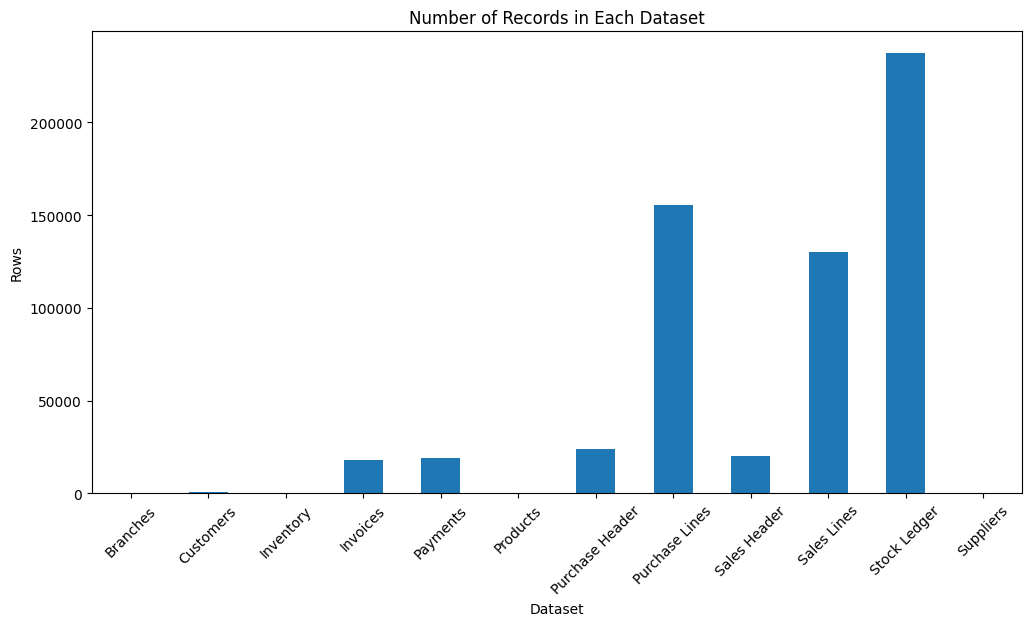

In [41]:
summary.plot(
    x="Dataset",
    y="Rows",
    kind="bar",
    figsize=(12,6),
    legend=False
)

plt.title("Number of Records in Each Dataset")
plt.ylabel("Rows")
plt.xticks(rotation=45)
plt.show()

Cell 11 - Missing Values Visualization

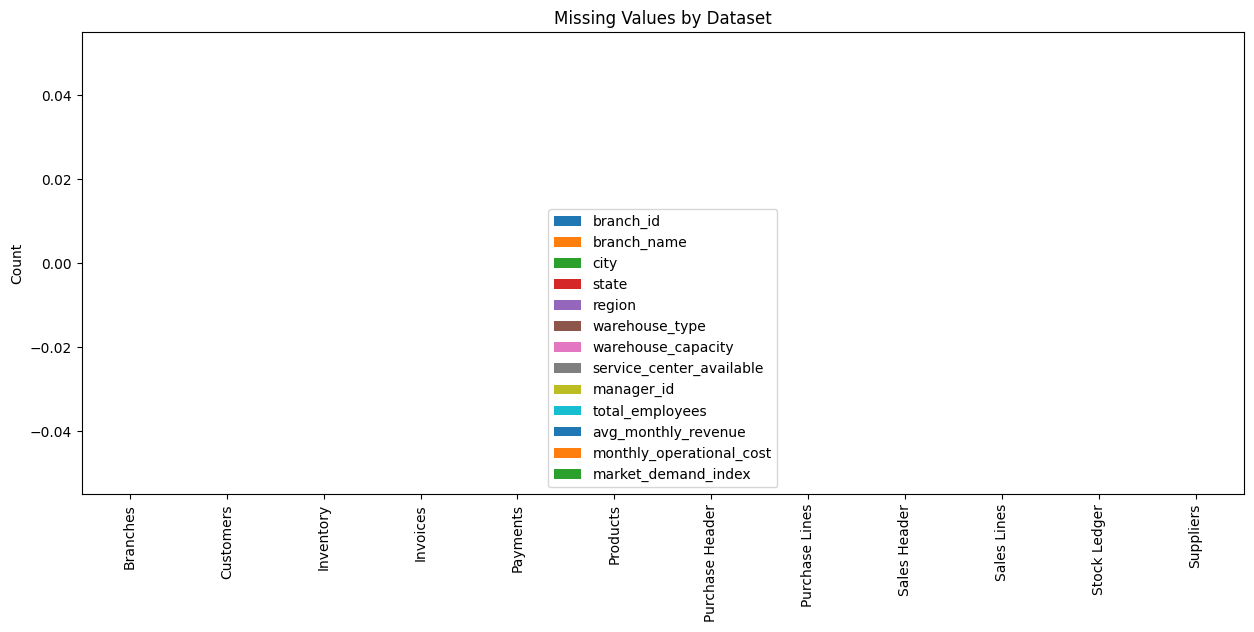

In [42]:
missing = pd.DataFrame()

for name, df in datasets.items():
    missing[name] = df.isnull().sum()

missing.T.plot(
    kind="bar",
    figsize=(15,6)
)

plt.title("Missing Values by Dataset")
plt.ylabel("Count")
plt.show()

Cell 12 - Initial Observations

In [43]:
print("Initial Observations")

print("-"*40)

print(f"Total datasets : {len(datasets)}")

print(f"Largest dataset : {summary.loc[summary['Rows'].idxmax(),'Dataset']}")

print(f"Smallest dataset : {summary.loc[summary['Rows'].idxmin(),'Dataset']}")

print(f"Total Records : {summary['Rows'].sum():,}")

Initial Observations
----------------------------------------
Total datasets : 12
Largest dataset : Stock Ledger
Smallest dataset : Branches
Total Records : 605,141


Cell 13 - Data Types Summary

In [44]:
for name, df in datasets.items():
    print(f"\n{name}")
    display(df.dtypes.reset_index().rename(columns={"index":"Column",0:"Data Type"}))


Branches


,Column,Data Type
0,branch_id,object
1,branch_name,object
2,city,object
3,state,object
4,region,object
5,warehouse_type,object
6,warehouse_capacity,object
7,service_center_available,object
8,manager_id,int64
9,total_employees,int64



Customers


,Column,Data Type
0,customer_id,object
1,customer_type,object
2,industry_segment,object
3,city,object
4,state,object
5,pincode,int64
6,region,object
7,branch_id,object
8,credit_limit,int64
9,current_balance,int64



Inventory


...

,Column,Data Type
0,so_id,object
1,line_number,int64
2,product_id,object
3,quantity,int64
4,unit_price,int64
5,gst_rate,int64
6,line_total,int64
7,gst_amount,float64
8,line_grand_total,float64



Stock Ledger


,Column,Data Type
0,movement_id,object
1,product_id,object
2,branch_id,object
3,movement_type,object
4,movement_date,object
5,quantity,int64
6,reference_type,object
7,reference_id,object
8,running_balance,int64



Suppliers


,Column,Data Type
0,supplier_id,object
1,supplier_name,object
2,supplier_type,object
3,product_category,object
4,city,object
5,province,object
6,region,object
7,pincode,int64
8,lead_time_days,int64
9,reliability_score,int64


Cell 14 - Unique Values

In [45]:
for name, df in datasets.items():
    print("="*60)
    print(name)
    print("="*60)

    categorical = df.select_dtypes(include="object").columns

    for col in categorical:
        print(f"{col}: {df[col].nunique()} unique values")

Branches
branch_id: 6 unique values
branch_name: 6 unique values
city: 6 unique values
state: 6 unique values
region: 4 unique values
warehouse_type: 4 unique values
warehouse_capacity: 6 unique values
service_center_available: 2 unique values
Customers
customer_id: 500 unique values
customer_type: 5 unique values
industry_segment: 6 unique values
city: 21 unique values
state: 16 unique values
region: 6 unique values
branch_id: 6 unique values
payment_terms: 5 unique values
customer_since: 467 unique values
last_purchase_date: 449 unique values
Inventory
product_id: 30 unique values
branch_id: 6 unique values
warehouse_bin: 95 unique values
Invoices
invoice_id: 17836 unique values
so_id: 18033 unique values
customer_id: 500 unique values
branch_id: 6 unique values
invoice_date: 2203 unique values
due_date: 2235 unique values
payment_status: 3 unique values
Payments
payment_id: 19055 unique values
invoice_id: 16036 unique values
payment_date: 2243 unique values
payment_method: 5 unique 

Cell 15 - Memory Usage

In [46]:
memory = []

for name, df in datasets.items():
    memory.append({
        "Dataset": name,
        "Memory(MB)": round(df.memory_usage(deep=True).sum()/1024**2,2)
    })

pd.DataFrame(memory)

,Dataset,Memory(MB)
0,Branches,0.00
1,Customers,0.29
2,Inventory,0.03
3,Invoices,7.28
4,Payments,4.43
5,Products,0.02
6,Purchase Header,9.71
7,Purchase Lines,24.76
8,Sales Header,9.19
9,Sales Lines,20.77


Cell 16 - Dataset Quality Score

In [47]:
quality = []

for name, df in datasets.items():

    missing = df.isnull().sum().sum()
    duplicate = df.duplicated().sum()

    quality.append({
        "Dataset": name,
        "Rows": len(df),
        "Missing Values": missing,
        "Duplicate Rows": duplicate
    })

quality_df = pd.DataFrame(quality)

quality_df

,Dataset,Rows,Missing Values,Duplicate Rows
0,Branches,6,0,0
1,Customers,500,0,0
2,Inventory,180,0,0
3,Invoices,18033,0,0
4,Payments,19257,0,0
5,Products,30,0,0
6,Purchase Header,24000,2370,0
7,Purchase Lines,155495,0,0
8,Sales Header,20000,0,0
9,Sales Lines,130402,0,0


Cell 17 - Business Questions

In [48]:
business_questions = [
    "Which products are fast moving?",
    "Which products are dead stock?",
    "Which supplier performs best?",
    "Which warehouse has highest inventory?",
    "What is inventory turnover?",
    "Which branch generates highest sales?",
    "Which products should be reordered?",
    "Which customers generate maximum revenue?",
    "What is warehouse utilization?",
    "Can demand be forecasted accurately?"
]

for i, q in enumerate(business_questions,1):
    print(f"{i}. {q}")

1. Which products are fast moving?
2. Which products are dead stock?
3. Which supplier performs best?
4. Which warehouse has highest inventory?
5. What is inventory turnover?
6. Which branch generates highest sales?
7. Which products should be reordered?
8. Which customers generate maximum revenue?
9. What is warehouse utilization?
10. Can demand be forecasted accurately?


Cell 18 - Proposed KPIs

In [49]:
kpis = [
    "Total Sales",
    "Inventory Value",
    "Inventory Turnover",
    "Dead Stock %",
    "Warehouse Utilization",
    "Supplier Performance",
    "Average Order Value",
    "Stockout Rate",
    "Top Selling Products",
    "Customer Lifetime Value"
]

for i,k in enumerate(kpis,1):
    print(f"{i}. {k}")

1. Total Sales
2. Inventory Value
3. Inventory Turnover
4. Dead Stock %
5. Warehouse Utilization
6. Supplier Performance
7. Average Order Value
8. Stockout Rate
9. Top Selling Products
10. Customer Lifetime Value
